In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns

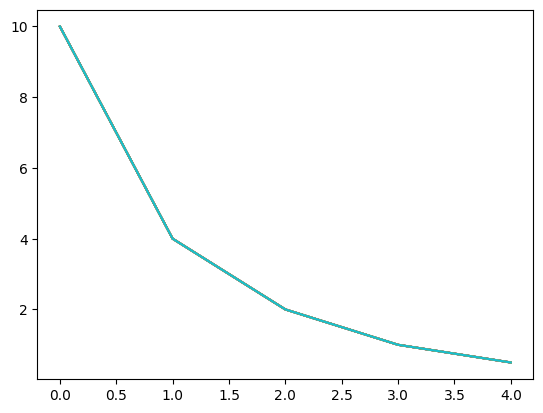

In [2]:
N_p = 10 # patients
N_t = 5 # time points (number of)
sc = 12 # scaling factor

y0 = np.zeros((N_p, N_t)) + np.array([10, 4, 2, 1, .5])

plt.plot(y0.T)
plt.show()

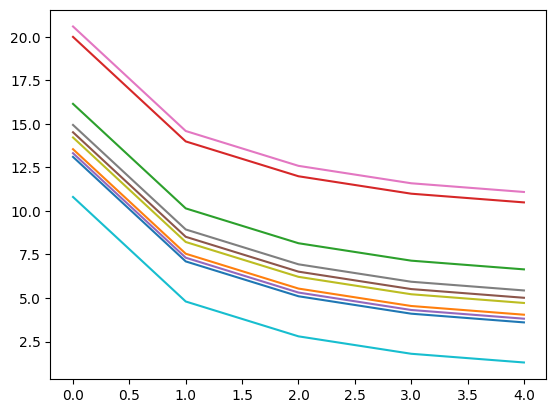

In [3]:
y_add = y0 + np.random.rand(N_p)[:, None] * sc

plt.plot(y_add.T)
plt.show()

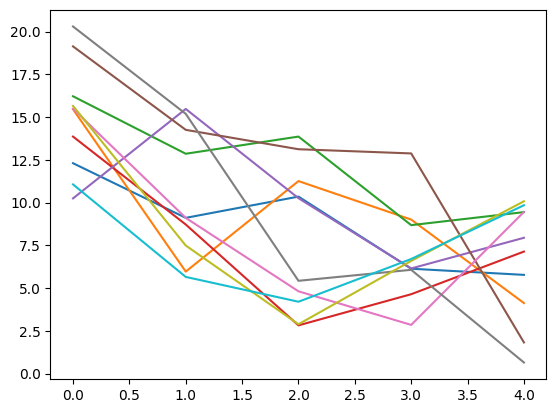

In [4]:
y_mult = y0 + np.random.rand(N_p, N_t) * sc

plt.plot(y_mult.T)
plt.show()

In [5]:
df_add = pd.DataFrame(data=y_add, columns=[f'T{i}' for i in range(N_t)])
df_add['Patient'] = np.arange(N_p) + 100
df_add = pd.melt(df_add, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_add, groups='Patient').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:               MixedLM   Dependent Variable:   y       
No. Observations:    50        Method:               REML    
No. Groups:          10        Scale:                0.0000  
Min. group size:     5         Log-Likelihood:       312.4152
Max. group size:     5         Converged:            Yes     
Mean group size:     5.0                                     
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   15.115     0.433       34.912 0.000 14.266 15.964
Week[T.T1]  -6.000     0.000  -720692.766 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000  -960923.688 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -1081039.149 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -1141096.880 0.000 -9.500 -9.500
Patient Var  1.874 23732.129                                 
=============================================================

"""

In [6]:
model.fe_params.to_numpy().shape

(5,)

In [7]:
np.empty(5).shape

(5,)

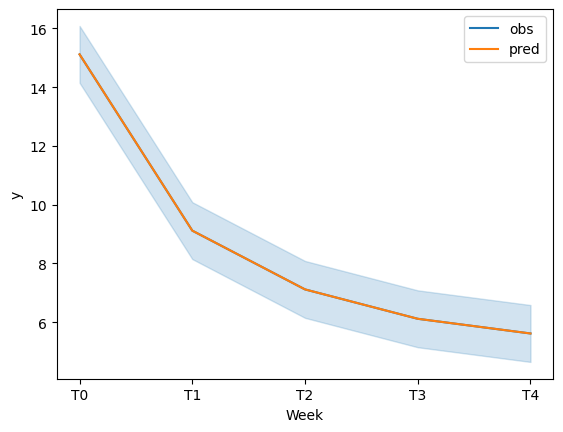

In [8]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_add, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [9]:
kill = np.random.randint(low=0, high=50, size=20)
df_add_kill = df_add.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_add_kill, groups='Patient').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:              MixedLM   Dependent Variable:   y       
No. Observations:   32        Method:               REML    
No. Groups:         10        Scale:                0.0000  
Min. group size:    2         Log-Likelihood:       136.3216
Max. group size:    4         Converged:            Yes     
Mean group size:    3.2                                     
------------------------------------------------------------
            Coef.   Std.Err.      z      P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept   15.115     0.559      27.043 0.000 14.020 16.210
Week[T.T1]  -6.000     0.000 -408408.516 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -420964.426 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -594508.038 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -608350.010 0.000 -9.500 -9.500
Patient Var  3.124 38147.441                                
============================================================

"""

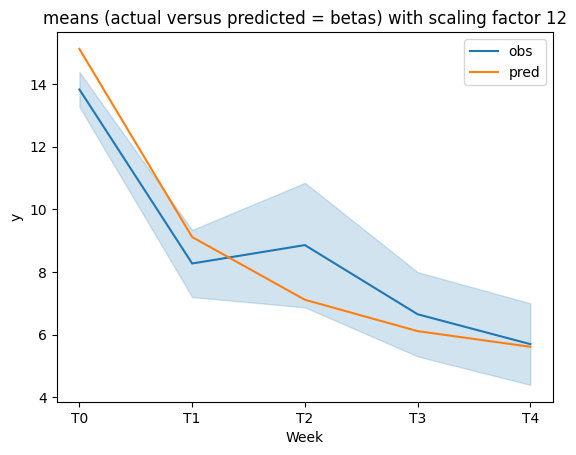

In [10]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()

# bi + b0 = mean(timepoint i) for i != 0
b[1:] += b[0] 
sem[1:] += sem[0]

sns.lineplot(data=df_add_kill, x='Week', y='y', errorbar='se', label = 'obs')
plt.plot(b,label = 'pred')

plt.legend()
plt.title(f"means (actual versus predicted = betas) with scaling factor {sc}")
plt.show()

## Multiplicative differences

In [11]:
df_mult = pd.DataFrame(data=y_mult, columns=[f'T{i}' for i in range(N_t)])
df_mult['Patient'] = np.arange(N_p) + 100
df_mult = pd.melt(df_mult, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

# log transform it
#df_mult['y'] = np.log(df_mult['y'])

model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient', re_formula = '~Week').fit()

model.summary()

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/home/UWO/mporwal2/Docume

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Mixed Linear Model Regression Results
=======================================================================
Model:                  MixedLM      Dependent Variable:      y        
No. Observations:       50           Method:                  REML     
No. Groups:             10           Scale:                   3.4603   
Min. group size:        5            Log-Likelihood:          -119.3376
Max. group size:        5            Converged:               No       
Mean group size:        5.0                                            
-----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------
Intercept                   14.977    0.800 18.722 0.000  13.409 16.545
Week[T.T1]                  -4.591    1.128 -4.070 0.000  -6.802 -2.380
Week[T.T2]                  -7.073    1.447 -4.887 0.000  -9.910 -4.236
Week[T.T3]                  -8.003    1.030 -7.770 0.000 -10.021 -5.984
Week[T.T4]                  -8.346    1.573 -5.305 0.000 -11.429 -5.262
Patient Var                  2.939    1.690                            
Patient x Week[T.T1] Cov     0.549    1.365                            
Week[T.T1] Var               5.804    3.917                            
Patient x Week[T.T2] Cov    -0.036    1.822                            
Week[T.T1] x Week[T.T2] Cov  3.629    3.294                            
Week[T.T2] Var              14.028    6.504                            
Patient x Week[T.T3] Cov    -0.396    1.646                            
Week[T.T1] x Week[T.T3] Cov -0.061    2.274                            
Week[T.T2] x Week[T.T3] Cov  4.330    3.976                            
Week[T.T3] Var               3.687    1.987                            
Patient x Week[T.T4] Cov    -6.634    2.620                            
Week[T.T1] x Week[T.T4] Cov -1.606    2.667                            
Week[T.T2] x Week[T.T4] Cov -0.927    3.654                            
Week[T.T3] x Week[T.T4] Cov  1.821    2.820                            
Week[T.T4] Var              17.829    6.835                            
=======================================================================

"""

In [19]:
# catch warnings
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
store_exceptions = []
try:
    with warnings.catch_warnings():
        warnings.filterwarnings('error', category = ConvergenceWarning)
        model = smf.mixedlm('y ~ Week', data=df_mult, groups='Patient', re_formula = '~Week').fit()
    a, b = model.fe_params.to_numpy(), True
except Exception as e:
    store_exceptions.append(e)
    print('no')


no


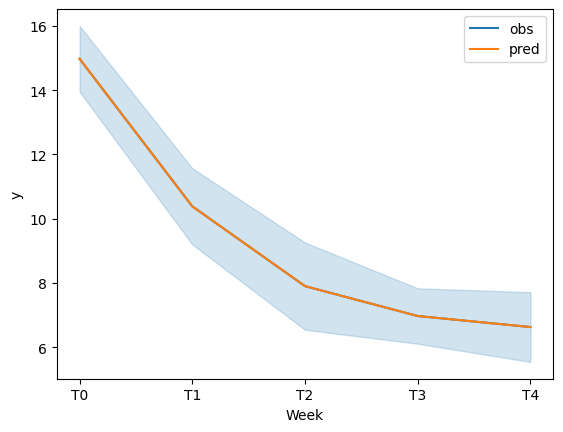

In [13]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [14]:
# same values killed as with the additive model
df_mult_kill = df_mult.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_mult_kill, groups='Patient', re_formula = '~Week').fit()

model.summary()


/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2704: RuntimeWarning: invalid value encountered in sqrt
  sdf[0:self.k_fe, 1] = np.sqrt(np.diag(s

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Mixed Linear Model Regression Results
========================================================================
Model:                  MixedLM       Dependent Variable:       y       
No. Observations:       32            Method:                   REML    
No. Groups:             10            Scale:                    3.3158  
Min. group size:        2             Log-Likelihood:           -74.7867
Max. group size:        4             Converged:                Yes     
Mean group size:        3.2                                             
------------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------------------
Intercept                    14.398    0.903 15.936 0.000  12.627 16.169
Week[T.T1]                   -4.560    1.474 -3.094 0.002  -7.449 -1.671
Week[T.T2]                   -5.199                                     
Week[T.T3]                   -7.064    1.096 -6.446 0.000  -9.211 -4.916
Week[T.T4]                   -7.185    1.733 -4.146 0.000 -10.582 -3.789
Patient Var                   6.006    2.920                            
Patient x Week[T.T1] Cov     -1.892    2.363                            
Week[T.T1] Var               11.068    6.379                            
Patient x Week[T.T2] Cov      1.311                                     
Week[T.T1] x Week[T.T2] Cov   1.938    3.231                            
Week[T.T2] Var                6.384    2.662                            
Patient x Week[T.T3] Cov     -0.464    1.611                            
Week[T.T1] x Week[T.T3] Cov   0.979                                     
Week[T.T2] x Week[T.T3] Cov   1.020                                     
Week[T.T3] Var                2.280                                     
Patient x Week[T.T4] Cov    -10.444    4.016                            
Week[T.T1] x Week[T.T4] Cov  -2.034                                     
Week[T.T2] x Week[T.T4] Cov  -4.672                                     
Week[T.T3] x Week[T.T4] Cov   3.265                                     
Week[T.T4] Var               26.549    6.690                            
========================================================================

"""

/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2458: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params())[0:p])


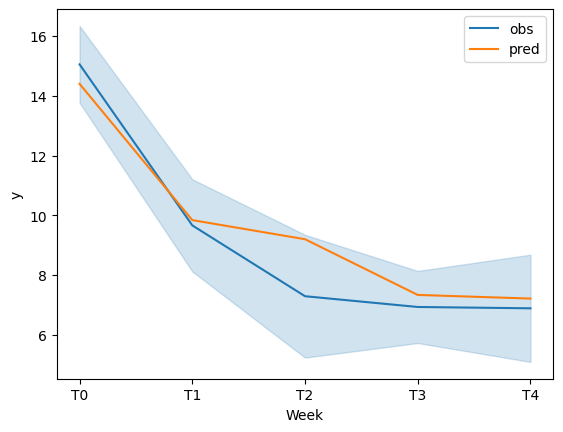

In [15]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_mult_kill, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)